# Homework 2: Functions, Merging & Visualization

This assignment synthesizes concepts from the Week 4 practice notebooks. Use the table below as a reference for where each function was introduced.

### **Concept Reference Map**

| Category | Concept / Function | Original Reference Notebook |
| :--- | :--- | :--- |
| **Data Exploration** | `info()`, `columns`, `unique()`, `head()` | `1-visualization_basics.ipynb` |
| **Statistics** | `describe()`, `mean()`, `pct_change()` | `1-visualization_basics.ipynb` |
| **Manipulation** | `rename()`, `query()`, `drop()`, `set_index()` | `1-visualization_basics.ipynb` / `2-merging_practice.ipynb` |
| **Aggregation** | `groupby()` | `1-visualization_basics.ipynb` |
| **Time Series** | `pd.to_datetime()`, `PeriodIndex` | `2-merging_practice.ipynb` |
| **Merging** | `pd.merge()`, `pd.concat()` | `2-merging_practice.ipynb` |
| **Visualization** | `plot()`, `scatter()`, `barh()` | `1-visualization_basics.ipynb` |

---

## A. Importing Data

Run the cell below to load the WorldBank API function and download population and GDP data for G7 countries.

In [163]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

def get_wb_data(indicator, countries_list, start_year, end_year):
    country_str = ';'.join(countries_list)
    url = f'https://api.worldbank.org/v2/country/{country_str}/indicator/{indicator}?date={start_year}:{end_year}&format=json&per_page=1000'
    response = requests.get(url)
    data = response.json()[1]
    df = pd.json_normalize(data)
    return df[['countryiso3code', 'date', 'value']]

## A.1 Show info

In [164]:
response = requests.get('https://api.worldbank.org/v2/country?format=json&per_page=300')
all_countries = response.json()[1]
country_lookup = {c['name']: c['id'] for c in all_countries}

g7_names = ['Japan', 'France', 'Germany', 'United States', 'Canada', 'Italy', 'United Kingdom']
g7 = [country_lookup[name] for name in g7_names]
print(g7)

['JPN', 'FRA', 'DEU', 'USA', 'CAN', 'ITA', 'GBR']


In [165]:
inflation_df = get_wb_data('FP.CPI.TOTL.ZG', g7, 2000, 2022)
inflation_df.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   countryiso3code  161 non-null    object 
 1   date             161 non-null    object 
 2   value            161 non-null    float64
dtypes: float64(1), object(2)
memory usage: 3.9+ KB


## A.2 Show column names


In [166]:
print(inflation_df.columns)

Index(['countryiso3code', 'date', 'value'], dtype='object')


## A.3 Show unique countries

In [167]:
print(inflation_df.countryiso3code.unique())

['CAN' 'DEU' 'FRA' 'GBR' 'ITA' 'JPN' 'USA']


# 1. Show GDP Growth for Japan using above data

## 1.A Rename column for country and value

In [168]:
# Rename country and value columns
inflation_df = inflation_df.rename({"countryiso3code" : "ZACOUNTRY", "value" : "HAPPYINFLATION"}, axis=1)
print(inflation_df.head(2))

  ZACOUNTRY  date  HAPPYINFLATION
0       CAN  2022        6.802801
1       CAN  2021        3.395193


## 1.1 Create new data with only Japan

In [169]:
df_jp = inflation_df.query("ZACOUNTRY == 'JPN'")
print(df_jp.head(10))

    ZACOUNTRY  date  HAPPYINFLATION
115       JPN  2022        2.497703
116       JPN  2021       -0.233353
117       JPN  2020       -0.024996
118       JPN  2019        0.468776
119       JPN  2018        0.989095
120       JPN  2017        0.484200
121       JPN  2016       -0.127259
122       JPN  2015        0.795280
123       JPN  2014        2.759227
124       JPN  2013        0.335038


## 1.2 Set index as date, sort index, and drop country column

In [170]:
# Set index 
df_jp = df_jp.set_index("date")
print(df_jp.head(2))

     ZACOUNTRY  HAPPYINFLATION
date                          
2022       JPN        2.497703
2021       JPN       -0.233353


In [171]:
# DROP country column
df_jp = df_jp.drop(['ZACOUNTRY'], axis='columns')
print(df_jp.head(2))

      HAPPYINFLATION
date                
2022        2.497703
2021       -0.233353


In [172]:
# Sort index makes it so date is descending
df_jp = df_jp.sort_index(ascending=False)
print(df_jp.head(10))

      HAPPYINFLATION
date                
2022        2.497703
2021       -0.233353
2020       -0.024996
2019        0.468776
2018        0.989095
2017        0.484200
2016       -0.127259
2015        0.795280
2014        2.759227
2013        0.335038


## 1.3 Plot

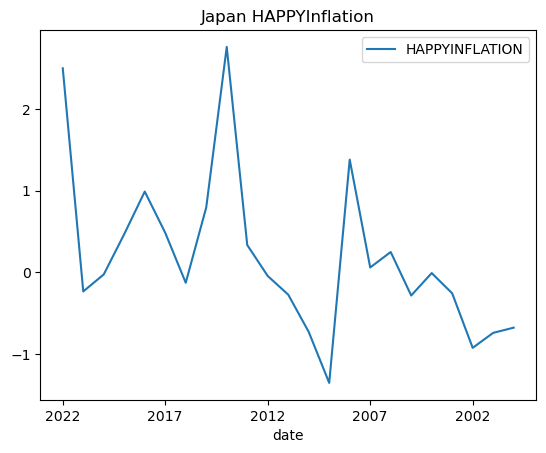

In [173]:
df_jp.plot()
plt.title("Japan HAPPYInflation");

# 2. Merging Data
## 2.A Importing data

In [174]:
df_gdp = pd.read_csv("../../../data/hw/hw_2/eichengreen_1.csv")
df_gdp.head(2)

,economy,date,country,gdp_pc_ppp,gdp_ppp,ir_spread,cred_priv_sec,bureaucracy_qual,corruption,investment_profile,law_order,exchange_rate,sd_interbank
0,BR,1997,Brunei,63095.776415,19683.232219,NaN,NaN,3.291667,4.000000,9.750000,6.0,0.020075,NaN
1,BR,1998,Brunei,62020.909406,19793.601111,NaN,NaN,3.000000,3.583333,7.583333,6.0,0.039924,NaN


In [175]:
df_govt_bond = pd.read_csv("../../../data/hw/hw_2/eichengreen_2.csv")
df_govt_bond.head(2)

,economy,date,country,net_borrow,kai,kao,bank_con,legor_uk,dist_eq,bond_market_cap,bo_plbn_scaled,bo_siln_scaled,bo_pabr_scaled,bo_siar_scaled
0,BR,1997,Brunei,11.062,0.1,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN
1,BR,1998,Brunei,14.424,0.1,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN


## 2.1 Filter one country

In [176]:
df_govt_bond.economy.unique()

array(['BR', 'CN', 'HK', 'ID', 'JP', 'KH', 'KR', 'LA', 'MM', 'MY', 'PH',
       'SG', 'TH', 'VN'], dtype=object)

In [177]:
df_govt_bond_vn = df_govt_bond.query("economy == 'VN'")
df_govt_bond_vn.head(2)

,economy,date,country,net_borrow,kai,kao,bank_con,legor_uk,dist_eq,bond_market_cap,bo_plbn_scaled,bo_siln_scaled,bo_pabr_scaled,bo_siar_scaled
299,VN,1997,Vietnam,NaN,1.000000,0.714286,84.50824,0.0,2338.550049,NaN,NaN,NaN,NaN,NaN
300,VN,1998,Vietnam,NaN,0.888889,1.000000,84.61529,0.0,2338.550049,NaN,NaN,NaN,NaN,NaN


In [178]:
#MAKE SURE YOU GET GDP Data df_gdp
df_gdp_vn = df_gdp.query("economy == 'VN'")
df_gdp_vn.head(2)

,economy,date,country,gdp_pc_ppp,gdp_ppp,ir_spread,cred_priv_sec,bureaucracy_qual,corruption,investment_profile,law_order,exchange_rate,sd_interbank
299,VN,1997,Vietnam,1709.896773,131889.833685,5.904167,19.848841,2.0,2.416667,6.583333,5.0,0.013462,NaN
300,VN,1998,Vietnam,1805.815779,141062.581723,5.170000,20.123863,2.0,2.000000,5.166667,5.0,0.024974,NaN


## 2.2 Filter gdp_pc_pp and set date as index

In [179]:
df_gdp_vn = df_gdp.query("economy == 'VN'")[['date', 'gdp_pc_ppp']].set_index('date').dropna().sort_index()
df_gdp_vn.head(2)

,gdp_pc_ppp
date,
1997,1709.896773
1998,1805.815779


In [180]:
df_govt_bond_vn = df_govt_bond.query("economy == 'VN'")[['date', 'net_borrow']].set_index("date").sort_index()
df_govt_bond_vn.head(2)

,net_borrow
date,
1997,NaN
1998,NaN


In [181]:
df_govt_bond_vn = df_govt_bond.query("economy == 'VN'")[['date', 'net_borrow']].set_index("date").dropna().sort_index()
df_govt_bond_vn.head(2)

,net_borrow
date,
1999,0.126
2000,1.582


## 2.3 Merge data

In [182]:
print(df_gdp_vn.index)
print(df_govt_bond_vn.index)

Index([1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008,
       2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018],
      dtype='int64', name='date')
Index([1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019],
      dtype='int64', name='date')


In [183]:
# NOTE I sorted index and drop na

def merge_data(df_gdp_vn, df_govt_bond_vn):
    df_merge = pd.merge(
        df_gdp_vn,
        df_govt_bond_vn,
        right_index=True,
        left_index=True,
        how='inner'
    )
    return df_merge

df_merge = merge_data(df_gdp_vn, df_govt_bond_vn)
df_merge.head(5)

,gdp_pc_ppp,net_borrow
date,,
1999,1896.989470,0.126
2000,2048.363759,1.582
2001,2200.020240,2.038
2002,2353.000468,2.784
2003,2538.163204,2.355


## 2.4 Convert to datetime

In [184]:
# No code changes needed
df_merge.index = pd.to_datetime(df_merge.index, format = "%Y")
df_merge.head(2)

,gdp_pc_ppp,net_borrow
date,,
1999-01-01,1896.989470,0.126
2000-01-01,2048.363759,1.582


## 2.4 Plot net_borrow

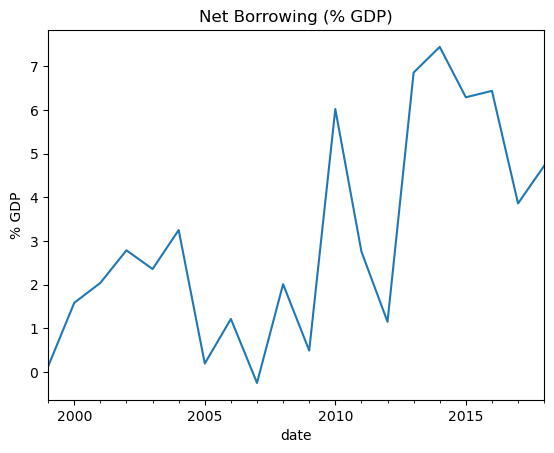

In [185]:
df_merge['net_borrow'].plot()
plt.title("Net Borrowing (% GDP)")
plt.ylabel("% GDP")
plt.xlabel("date")
plt.show()

# 3. Functions

## 3.A Import Data

In [203]:
df_gdp = pd.read_csv("../../../data/hw/hw_2/eichengreen_1.csv")
df_govt_bond = pd.read_csv("../../../data/hw/hw_2/eichengreen_2.csv")
df_merge_all = pd.concat([df_gdp, df_govt_bond], axis = 'columns')
df_merge_all.columns

Index(['economy', 'date', 'country', 'gdp_pc_ppp', 'gdp_ppp', 'ir_spread',
       'cred_priv_sec', 'bureaucracy_qual', 'corruption', 'investment_profile',
       'law_order', 'exchange_rate', 'sd_interbank', 'economy', 'date',
       'country', 'net_borrow', 'kai', 'kao', 'bank_con', 'legor_uk',
       'dist_eq', 'bond_market_cap', 'bo_plbn_scaled', 'bo_siln_scaled',
       'bo_pabr_scaled', 'bo_siar_scaled'],
      dtype='object')

In [204]:
df_merge_all = pd.merge(df_gdp, df_govt_bond, on=['economy', 'date', 'country'])
df_merge_all.columns

Index(['economy', 'date', 'country', 'gdp_pc_ppp', 'gdp_ppp', 'ir_spread',
       'cred_priv_sec', 'bureaucracy_qual', 'corruption', 'investment_profile',
       'law_order', 'exchange_rate', 'sd_interbank', 'net_borrow', 'kai',
       'kao', 'bank_con', 'legor_uk', 'dist_eq', 'bond_market_cap',
       'bo_plbn_scaled', 'bo_siln_scaled', 'bo_pabr_scaled', 'bo_siar_scaled'],
      dtype='object')

## 3.1 Create function to convert to datetime

In [210]:
df_gdp_bn = df_gdp.query("economy == 'BR'")
df_govt_bond_bn = df_govt_bond.query("economy == 'BR'").reset_index()

In [211]:
def convert_datetime(df_gdp, df_govt_bond):
    df_gdp['date'] = pd.PeriodIndex(df_gdp['date'], freq='Q').to_timestamp() #.date
    df_govt_bond['date'] = pd.to_datetime(df_govt_bond['date'], format='%Y')#.dt.date
    return df_gdp, df_govt_bond

df_gdp_bn_dt, df_govt_bond_bn_dt = convert_datetime(df_gdp_bn.copy(), df_govt_bond_bn.copy())

In [213]:
df_merge_all = pd.merge(df_gdp_bn_dt, df_govt_bond_bn_dt, on=['economy', 'date', 'country'])
df_merge_all.head(5)

,economy,date,country,gdp_pc_ppp,gdp_ppp,ir_spread,cred_priv_sec,bureaucracy_qual,corruption,investment_profile,...,kai,kao,bank_con,legor_uk,dist_eq,bond_market_cap,bo_plbn_scaled,bo_siln_scaled,bo_pabr_scaled,bo_siar_scaled
0,BR,1997-01-01,Brunei,63095.776415,19683.232219,NaN,NaN,3.291667,4.000000,9.750000,...,0.1,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN
1,BR,1998-01-01,Brunei,62020.909406,19793.601111,NaN,NaN,3.000000,3.583333,7.583333,...,0.1,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN
2,BR,1999-01-01,Brunei,63432.255561,20692.236087,NaN,60.176555,3.000000,3.000000,7.250000,...,0.1,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN
3,BR,2000-01-01,Brunei,65305.765574,21757.595387,NaN,50.293146,3.000000,3.000000,8.000000,...,0.1,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN
4,BR,2001-01-01,Brunei,67184.354498,22844.964797,NaN,53.633142,3.000000,2.666667,10.625000,...,0.1,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN


## 3.2 Rename column function

In [218]:
df_merge_all = pd.merge(df_gdp, df_govt_bond, on=['economy', 'date', 'country'])
df_merge_all_converted = df_merge_all.copy()
df_merge_all_converted['date'] = pd.to_datetime(df_merge_all_converted['date'], format='%Y')

C:\Users\hayde\AppData\Local\Temp\ipykernel_45932\3285036029.py:5: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  plt.scatter(df_plot['gdp_pc_ppp'].pct_change(1), df_plot['net_borrow'])


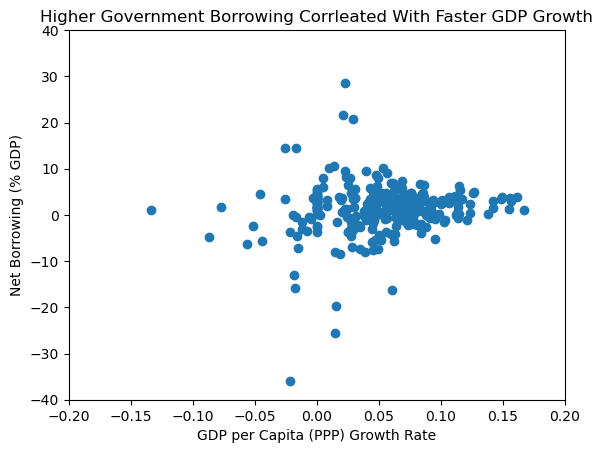

In [220]:
def plot_scatter(x_title, y_title, main_title):
    df_plot = df_merge_all_converted
    
    # Define the columns for x and y
    plt.scatter(df_plot['gdp_pc_ppp'].pct_change(1), df_plot['net_borrow'])
    plt.xlabel('GDP per Capita (PPP) Growth Rate')
    plt.ylabel('Net Borrowing (% GDP)')
    plt.title('Higher Government Borrowing Corrleated With Faster GDP Growth')
    plt.xlim(-0.2, 0.2)
    plt.ylim(-40, 40)
    plt.show ()

# Note corrleation does not equal causation :)
plot_scatter('GDP per Capita (PPP)', 'Net Borrowing', 'Higher Government Borrowing Corrleated With Faster GDP Growth')